### Setup

In [1]:
!pip install openai biopython sentence-transformers faiss-cpu requests python-dotenv neo4j langchain-openai

## RAG Helpers


In [ ]:
import os
from Bio import Entrez  # [web:35]
import re
Entrez.email = ""  # required by NCBI
Entrez.tool = "pubmed-rag-demo"

os.environ["OPENROUTER_API_KEY"] = ""


In [3]:
import json
from Bio import Entrez  # [web:35]

from Bio import Entrez  # [web:35]

def pubmed_keyword_search(query: str, k: int = 5):
    # ESearch gets PMIDs, retmax controls how many IDs you receive. [web:76][web:82]
    h = Entrez.esearch(db="pubmed", term=query, retmax=k)
    r = Entrez.read(h)
    h.close()
    pmids = r.get("IdList", [])
    if not pmids:
        return []

    # EFetch gets titles/abstracts for those PMIDs. [web:76][web:82]
    h = Entrez.efetch(db="pubmed", id=",".join(pmids), rettype="abstract", retmode="xml")
    recs = Entrez.read(h)
    h.close()
    print("ESearch Count:", r["Count"], "Returning:", len(r["IdList"]))
    docs = []
    for article in recs["PubmedArticle"]:
        art = article["MedlineCitation"]["Article"]
        pmid = str(article["MedlineCitation"]["PMID"])
        title = str(art.get("ArticleTitle", ""))
        abstract_list = art.get("Abstract", {}).get("AbstractText", [])
        abstract = " ".join(str(x) for x in abstract_list)
        docs.append({"pmid": pmid, "title": title, "abstract": abstract})
    return docs


In [4]:
import numpy as np
from sentence_transformers import SentenceTransformer  # [web:24][web:30]

emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def semantic_topk_from_pubmed(query: str, k: int = 5, n_candidates: int = 100):
    # 1) Pull a candidate pool from PubMed keyword search (top-N by PubMed ranking).
    candidates = pubmed_keyword_search(query, k=n_candidates)
    if not candidates:
        return []

    # 2) Embed + cosine similarity rerank
    texts = [(d["title"] + " " + d["abstract"]).strip() for d in candidates]

    q_emb = emb_model.encode([query], convert_to_numpy=True).astype("float32")
    d_emb = emb_model.encode(texts, convert_to_numpy=True).astype("float32")

    q_emb /= (np.linalg.norm(q_emb, axis=1, keepdims=True) + 1e-12)
    d_emb /= (np.linalg.norm(d_emb, axis=1, keepdims=True) + 1e-12)

    scores = d_emb @ q_emb[0]
    order = np.argsort(-scores)[:k]

    results = []
    for idx in order:
        d = candidates[int(idx)]
        results.append({
            "score": float(scores[int(idx)]),
            "pmid": d["pmid"],
            "title": d["title"],
            "abstract": d["abstract"]
        })
    return results



In [22]:
from neo4j import GraphDatabase
import os

# Neo4j connection details
NEO4J_URI = "neo4j+s://95bdf5c7.databases.neo4j.io"
NEO4J_USERNAME = ""
NEO4J_PASSWORD = ""

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

def check_neo4j_connection():
    try:
        with driver.session() as session:
            result = session.run("RETURN 1 as n")
            if result.single()["n"] == 1:
                print("Successfully connected to Neo4j Aura!")
    except Exception as e:
        print(f"Connection failed: {e}")

check_neo4j_connection()


Connection failed: Failed to DNS resolve address 95bdf5c7.databases.neo4j.io:7687: [Errno 8] nodename nor servname provided, or not known


In [ ]:
import os
import textwrap
import requests  # [web:37][web:43]
from openai import OpenAI # type: ignore
OPENROUTER_API_KEY = ""
OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/"
GEMMA_MODEL = "google/gemma-3-12b"  # [web:28]
MEDGAMMA_MODEL = "google/medgemma-4b-it"
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key="",)

def build_context(docs, max_chars=4000):
    parts = []
    for i, d in enumerate(docs, start=1):
        snippet = d["abstract"][:1500]
        parts.append(f"[{i}] PMID: {d['pmid']}\nTitle: {d['title']}\nAbstract: {snippet}\n")
    ctx = "\n\n".join(parts)
    return ctx[:max_chars]

def build_rag_prompts(user_query, docs, is_mcq):
    ctx = build_context(docs)
    system_msg = (
        "You are a careful medical assistant. "
        "Use the information in the provided PubMed abstracts as a reference. "
    )
    if not is_mcq:
        user_msg = textwrap.dedent(f"""Question: {user_query} \n\nPubMed sources:\n{ctx}\n\nWhen answering:
    - Bias for Decision: If the provided data supports a 'yes' or 'no', you must lean toward that answer. Only use 'maybe' if the evidence is truly insufficient or directly contradictory.
    - Answer format: Put reasoning within <thinking> tags, and put your final answer which will be a 'yes', 'no', or a 'maybe' in <answer> tags.
    - Do not invent facts not in the abstracts.""")
    else:
        user_msg = textwrap.dedent(f"""Question: {user_query} \n\nPubMed sources:\n{ctx}\n\nWhen answering:
    - Bias for Decision: If the provided data supports a 'yes' or 'no', you must lean toward that answer. Only use 'maybe' if the evidence is truly insufficient or directly contradictory.
- Answer format: Put reasoning within <thinking> tags, and put your final answer which will be a 'A', 'B', 'C' or a 'D' in <answer> tags.
- Do not invent facts not in the abstracts.""")
    return system_msg, user_msg

def call_gemma(system_prompt, user_prompt, max_tokens=512):
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": GEMMA_MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "max_tokens": max_tokens,
        "temperature": 0.3,
    }
    # print(f"\n\nSystem_prompt:\n"+system_prompt )
    # print(f"\nUser_prompt:\n"+user_prompt)

    completion = client.chat.completions.create(
    extra_headers={
    "HTTP-Referer": "<YOUR_SITE_URL>", # Optional. Site URL for rankings on openrouter.ai.
    "X-OpenRouter-Title": "<YOUR_SITE_NAME>", # Optional. Site title for rankings on openrouter.ai.
    },
    extra_body={},
    model=GEMMA_MODEL,
    messages=[
     {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
  ]
)
    return (completion.choices[0].message.content)


In [7]:
def call_reasoner_qa(system_prompt, user_prompt):
    # Use the existing call_gemma function which is already configured
    return call_gemma(system_prompt, user_prompt)

def extract_entities_llm(query):
    system_prompt = "You are a medical assistant that extracts key medical entities from a question."
    user_prompt = f"Extract the 3-5 most important medical keywords (diseases, symptoms, drugs, body parts) from this question. Return only the keywords as a comma-separated list.\nQuestion: {query}"
    res = call_reasoner_qa(system_prompt, user_prompt)
    # Handle potential formatting issues
    keywords = [k.strip() for k in res.split(",") if k.strip()]
    # Clean up any potential markdown or extra text
    keywords = [k.split("\n")[0].replace("-", "").strip() for k in keywords]
    return keywords

In [ ]:
k = 5
query = "Length of external auditory canal is"

# A) PubMed's own keyword top-k
docs_pubmed = pubmed_keyword_search(query, k=k)

# B) Semantic similarity top-k (rerank top-100 PubMed candidates)
docs_semantic = semantic_topk_from_pubmed(query, k=k, n_candidates=100)

print("\n\n=== Pubmed Keyword RAG Prompts ===")
# Generate answer using PubMed keyword retrieval
sys1, usr1 = build_rag_prompts(query, docs_pubmed, True)
ans_pubmed = call_gemma(sys1, usr1)

print("=== Semantic RAG Prompts ===")
# Generate answer using semantic reranked retrieval
sys2, usr2 = build_rag_prompts(query, docs_semantic, True)
ans_semantic = call_gemma(sys2, usr2)

print("=== PubMed keyword RAG answer ===")
print(ans_pubmed)
print("\n=== Semantic-reranked RAG answer ===")
print(ans_semantic)

print("\nPubMed keyword PMIDs:", [d["pmid"] for d in docs_pubmed])
print("Semantic reranked PMIDs:", [d["pmid"] for d in docs_semantic])

## Test run on dataset pubmedQA

In [ ]:
import json
import re
from tqdm.auto import tqdm

# --- Configuration ---
QUESTIONS_FILE = "ori_pqal.json"
GROUND_TRUTH_FILE = "test_ground_truth.json"
NUM_SAMPLES = 20 # Number of test samples to evaluate

# --- Helper Function ---
def extract_answer(llm_output):
    """Parses the text to strictly extract the answer inside <answer> tags."""
    if not llm_output:
        return "unknown"
    match = re.search(r'<answer>(.*?)</answer>', llm_output, flags=re.IGNORECASE | re.DOTALL)
    if match:
        ans = match.group(1).strip().lower()
        ans = re.sub(r'[^a-z]', '', ans)
        if ans in ['yes', 'no', 'maybe']:
            return ans
    return "unknown"

# --- Load Datasets ---
print(f"Loading datasets...")
with open("ori_pqal.json", 'r', encoding='utf-8') as f:
    questions_data = json.load(f)

with open(GROUND_TRUTH_FILE, 'r', encoding='utf-8') as f:
    gt_data = json.load(f)

# Grab a subset of question IDs that exist in both files
common_ids = [q_id for q_id in gt_data.keys() if q_id in questions_data]
test_ids = common_ids[:NUM_SAMPLES]

if not test_ids:
    print("Error: No matching question IDs found between the two files!")

# Track Metrics
results = {
    "no_rag": {"correct": 0, "total": 0},
    "keyword_rag": {"correct": 0, "total": 0},
    "semantic_rag": {"correct": 0, "total": 0}
}

# --- Evaluation Loop ---
for q_id in tqdm(test_ids, desc="Evaluating RAG Pipelines"):
    # Extract Question
    q_entry = questions_data[q_id]
    query = q_entry.get("QUESTION", "")

    # Extract Ground Truth (Handles if GT is a direct string or nested in a dict)
    gt_entry = gt_data[q_id]
    if isinstance(gt_entry, dict):
        ground_truth = gt_entry.get("final_decision", "").strip().lower()
    else:
        # Sometimes test_ground_truth is just {"ID": "yes"}
        ground_truth = str(gt_entry).strip().lower()

    # --- 1. NO RAG ---
    sys_no_rag, usr_no_rag = build_rag_prompts(query, docs=[], is_mcq=False)
    out_no_rag = call_gemma(sys_no_rag, usr_no_rag)
    ans_no_rag = extract_answer(out_no_rag)

    if ans_no_rag == ground_truth:
        results["no_rag"]["correct"] += 1
    results["no_rag"]["total"] += 1

    # --- 2. KEYWORD RAG ---
    docs_keyword = pubmed_keyword_search(query, k=5)
    sys_kw, usr_kw = build_rag_prompts(query, docs=docs_keyword, is_mcq=False)
    out_kw = call_gemma(sys_kw, usr_kw)
    ans_kw = extract_answer(out_kw)

    if ans_kw == ground_truth:
        results["keyword_rag"]["correct"] += 1
    results["keyword_rag"]["total"] += 1

    # --- 3. SEMANTIC RAG ---
    docs_semantic = semantic_topk_from_pubmed(query, k=5, n_candidates=100)
    sys_sem, usr_sem = build_rag_prompts(query, docs=docs_semantic, is_mcq=False)
    out_sem = call_gemma(sys_sem, usr_sem)
    ans_sem = extract_answer(out_sem)

    if ans_sem == ground_truth:
        results["semantic_rag"]["correct"] += 1
    results["semantic_rag"]["total"] += 1

    # Live logging per question
    print(f"\n--- Question ID: {q_id} ---")
    print(f"Ground Truth:   {ground_truth}")
    print(f"No RAG Output:  {ans_no_rag}")
    print(f"Keyword RAG:    {ans_kw}")
    print(f"Semantic RAG:   {ans_sem}")

# --- Final Output ---
print("\n========== FINAL EVALUATION RESULTS ==========")
for mode, metric in results.items():
    acc = (metric["correct"] / metric["total"]) * 100 if metric["total"] > 0 else 0
    print(f"{mode.replace('_', ' ').upper()} Accuracy: {acc:.2f}% ({metric['correct']}/{metric['total']})")


Evaluation

In [9]:
import math
from collections import defaultdict
from scipy.stats import kendalltau

def ndcg_at_k(relevances, k):
    """
    relevances: list of relevance scores ordered by a ranking (e.g., semantic order)
    k: cutoff
    """
    k = min(k, len(relevances))
    if k == 0:
        return 0.0

    dcg = 0.0
    for i in range(k):
        rel = relevances[i]
        dcg += (2**rel - 1) / math.log2(i + 2)  # i=0 -> log2(2)=1

    # Ideal DCG: same scores sorted descending
    ideal = sorted(relevances, reverse=True)
    idcg = 0.0
    for i in range(k):
        rel = ideal[i]
        idcg += (2**rel - 1) / math.log2(i + 2)

    return dcg / idcg if idcg > 0 else 0.0

def ranking_positions(ranked_pmids):
    """Return dict: pmid -> rank index (0-based)."""
    return {pmid: i for i, pmid in enumerate(ranked_pmids)}

def kendalls_tau_between(rank_a, rank_b, universe_pmids):
    """
    rank_a, rank_b: dict pmid -> index
    universe_pmids: set of pmids that appear in at least one ranking

    For PMIDs missing in a ranking, we assign them worst rank = len(universe).
    """
    n = len(universe_pmids)
    if n < 2:
        return 0.0

    worst_rank_a = len(rank_a)
    worst_rank_b = len(rank_b)
    a_vals, b_vals = [], []
    for pmid in universe_pmids:
        a_vals.append(rank_a.get(pmid, worst_rank_a))
        b_vals.append(rank_b.get(pmid, worst_rank_b))
    tau, _ = kendalltau(a_vals, b_vals)
    return float(tau) if tau is not None else 0.0

def topk_overlap(list_a, list_b, k):
    """Fractional overlap of the top-k sets from two ranked lists."""
    top_a = set(list_a[:k])
    top_b = set(list_b[:k])
    if not top_a and not top_b:
        return 0.0
    return len(top_a & top_b) / len(top_a | top_b)


In [10]:
# Example: inspect one query from your dataset
example_qid = test_ids[0]  # or pick any ID
query = questions_data[example_qid]["QUESTION"]

k_pub = 20            # get top-20 from PubMed (native ranking)
k_sem = 20            # keep top-20 from semantic rerank
n_candidates = 50    # candidate pool for semantic rerank

print("Query:", query)

# A) PubMed native relevance ranking
docs_pub = pubmed_keyword_search(query, k=k_pub)
pmids_pub = [d["pmid"] for d in docs_pub]

# B) Our semantic ranking (rerank same query)
docs_sem = semantic_topk_from_pubmed(query, k=k_sem, n_candidates=n_candidates)
pmids_sem = [d["pmid"] for d in docs_sem]

print("\nPubMed top PMIDs:", pmids_pub)
print("Semantic top PMIDs:", pmids_sem)

# Build a simple "relevance" label: how high PubMed ranks each PMID
pub_ranks = ranking_positions(pmids_pub)
# Map semantic ranking into those relevance scores (lower rank = higher relevance)
semantic_rels = []
for pmid in pmids_sem:
    if pmid in pub_ranks:
        # Convert rank to a higher-is-better score; e.g., inverse rank
        # You can experiment with other transforms.
        semantic_rels.append(len(pmids_pub) - pub_ranks[pmid])
    else:
        semantic_rels.append(0)

k_eval = 10
ndcg_val = ndcg_at_k(semantic_rels, k=k_eval)

# Kendall's tau and top-k overlap
universe = set(pmids_pub) | set(pmids_sem)
sem_ranks = ranking_positions(pmids_sem)

tau_val = kendalls_tau_between(pub_ranks, sem_ranks, universe)
overlap_val = topk_overlap(pmids_pub, pmids_sem, k=k_eval)

print(f"\n=== Single-query metrics (k={k_eval}) ===")
print(f"nDCG@{k_eval} (semantic vs PubMed relevance): {ndcg_val:.3f}")
print(f"Kendall's tau (full lists): {tau_val:.3f}")
print(f"Top-{k_eval} overlap: {overlap_val:.3f}")


Query: Is anorectal endosonography valuable in dyschesia?
ESearch Count: 7 Returning: 7
ESearch Count: 7 Returning: 7

PubMed top PMIDs: ['36414477', '25746704', '18512062', '16832336', '12377809', '10499461', '7746437']
Semantic top PMIDs: ['12377809', '10499461', '18512062', '7746437', '36414477', '25746704', '16832336']

=== Single-query metrics (k=10) ===
nDCG@10 (semantic vs PubMed relevance): 0.526
Kendall's tau (full lists): -0.238
Top-10 overlap: 1.000


In [11]:
from tqdm.auto import tqdm

k_pub = 20
k_sem = 20
n_candidates = 50
k_eval = 10

ndcgs = []
taus = []
overlaps = []

for q_id in tqdm(test_ids, desc="Comparing rankings"):
    query = questions_data[q_id]["QUESTION"]

    # PubMed ranking
    docs_pub = pubmed_keyword_search(query, k=k_pub)
    pmids_pub = [d["pmid"] for d in docs_pub]
    if len(pmids_pub) == 0:
        continue

    # Semantic ranking
    docs_sem = semantic_topk_from_pubmed(query, k=k_sem, n_candidates=n_candidates)
    pmids_sem = [d["pmid"] for d in docs_sem]
    if len(pmids_sem) == 0:
        continue

    pub_ranks = ranking_positions(pmids_pub)
    sem_ranks = ranking_positions(pmids_sem)
    universe = set(pmids_pub) | set(pmids_sem)

    # Build semantic relevance scores based on PubMed positions
    semantic_rels = []
    for pmid in pmids_sem:
        if pmid in pub_ranks:
            semantic_rels.append(len(pmids_pub) - pub_ranks[pmid])
        else:
            semantic_rels.append(0)

    ndcgs.append(ndcg_at_k(semantic_rels, k_eval))
    taus.append(kendalls_tau_between(pub_ranks, sem_ranks, universe))
    overlaps.append(topk_overlap(pmids_pub, pmids_sem, k_eval))

print("\n===== Aggregate ranking metrics =====")
if ndcgs:
    print(f"Mean nDCG@{k_eval}: {sum(ndcgs)/len(ndcgs):.3f}")
if taus:
    print(f"Mean Kendall's tau: {sum(taus)/len(taus):.3f}")
if overlaps:
    print(f"Mean Top-{k_eval} overlap: {sum(overlaps)/len(overlaps):.3f}")
print(f"Number of queries evaluated: {len(ndcgs)}")


Comparing rankings:   0%|          | 0/20 [00:00<?, ?it/s]

ESearch Count: 7 Returning: 7
ESearch Count: 7 Returning: 7
ESearch Count: 5 Returning: 5
ESearch Count: 5 Returning: 5
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 9 Returning: 9
ESearch Count: 9 Returning: 9
ESearch Count: 15 Returning: 15
ESearch Count: 15 Returning: 15
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 2 Returning: 2
ESearch Count: 2 Returning: 2
ESearch Count: 2 Returning: 2
ESearch Count: 2 Returning: 2
ESearch Count: 14 Returning: 14
ESearch Count: 14 Returning: 14
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1
ESearch Count: 4 Returning: 4
ESearch Count: 4 Returning: 4
ESearch Count: 13 Returning: 13
ESearch Count: 13 Returning: 13
ESearch Count: 20 Returning: 20
ESearch Count: 20 Returning: 20
ESearch Count: 1 Returning: 1
ESearch Count: 1 Returning: 1

===== Aggregate ranking

Aggregate over 16 queries
Mean nDCG@10 = 0.715: across queries, your semantic ranking is reasonably aligned with PubMed—on average, top documents (by PubMed) still appear fairly high in your semantic list. Values closer to 1 would mean “almost identical quality order,” closer to 0 would be “random.”

Mean Kendall’s tau = -0.121: globally, your ordering is slightly negatively correlated with PubMed’s. That says your model tends to reshuffle positions quite a bit, and often in the opposite direction for many pairs of articles.

Mean Top‑10 overlap = 0.865: you and PubMed almost always choose largely the same set of top‑10 documents (86.5% overlap on average), even though you often rank them in a different order.



In [52]:
import numpy as np
class PubMedQAGraphRetriever:
    def __init__(self, driver, emb_model):
        self.driver = driver
        self.emb_model = emb_model
        self._all_nodes = []
        self._node_embs = None
        
    def refresh_nodes(self):
        print("Indexing nodes for vector search...")
        with self.driver.session() as session:
            result = session.run("MATCH (n:Entity) RETURN n.name as name")
            self._all_nodes = [record["name"] for record in result]
        
        if self._all_nodes:
            self._node_embs = self.emb_model.encode(self._all_nodes, show_progress_bar=True)
            self._node_embs /= (np.linalg.norm(self._node_embs, axis=1, keepdims=True) + 1e-12)
        return self

    def retrieve(self, query_keywords, top_k_nodes=3, threshold=0.6):
        if not self._all_nodes or self._node_embs is None:
            self.refresh_nodes()
        
        if not self._all_nodes:
            return ""
            
        # 1. Vector match keywords to nodes
        kw_embs = self.emb_model.encode(query_keywords)
        kw_embs /= (np.linalg.norm(kw_embs, axis=1, keepdims=True) + 1e-12)
        
        matched_entities = set()
        for kw_emb in kw_embs:
            scores = self._node_embs @ kw_emb
            best_indices = np.argsort(-scores)[:top_k_nodes]
            for idx in best_indices:
                if scores[idx] > threshold: 
                    matched_entities.add(self._all_nodes[idx])
        
        if not matched_entities:
            return "No matching graph entities found."
            
        # 2. Fetch context from Neo4j
        context_parts = []
        with self.driver.session() as session:
            for ent in matched_entities:
                cypher = """
                MATCH (s:Entity)-[r]->(o:Entity)
                WHERE s.name = $ent OR o.name = $ent
                RETURN s.name as s, type(r) as p, o.name as o, r.evidence as evidence, r.pmid as pmid
                LIMIT 10
                """
                result = session.run(cypher, ent=ent)
                for record in result:
                    snippet = f"Relationship: ({record['s']}) -[{record['p']}]-> ({record['o']})"
                    if record.get('evidence'):
                        snippet += f"\nSource Evidence: \"{record['evidence']}\""
                    context_parts.append(snippet)
        
        return "\n\n".join(list(set(context_parts)))

graph_retriever = PubMedQAGraphRetriever(driver, emb_model)

In [ ]:
import networkx as nx
import json
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import JsonOutputParser
from IPython.display import display, Markdown

# Use the same LLM instance we set up previously
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="",
    model="qwen/qwen3-8b"
)

# 1. Extraction Pipeline using Langchain
extract_prompt = PromptTemplate.from_template("""
Extract entities and relationships from the text below. 
Return the result strictly as a JSON list of objects with "subject", "predicate", and "object" keys.

Text: {text}
JSON:
""")

# The JsonOutputParser ensures the LLM's output is parsed directly into a Python list
extract_chain = extract_prompt | llm | JsonOutputParser()

def extract_triples_from_docs(docs):
    all_triples = []
    # Using the first 3 documents to avoid hitting rate limits quickly in this example
    for d in docs[:3]:
        text = d["title"] + ". " + d["abstract"]
        try:
            triples = extract_chain.invoke({"text": text})
            if isinstance(triples, list):
                all_triples.extend(triples)
        except Exception as e:
            print(f"Error parsing triples for PMID {d['pmid']}: {e}")
    return all_triples

# Let's extract some triples using the previous semantic search results
print("Extracting triples from documents...")
sample_triples = extract_triples_from_docs(docs_semantic)
print(f"Extracted {len(sample_triples)} triples.")

Extracting triples from documents...
Extracted 0 triples.


In [46]:
# 2. Graph Construction
G = nx.DiGraph()

for t in sample_triples:
    if isinstance(t, dict) and "subject" in t and "object" in t and "predicate" in t:
        subj = str(t["subject"]).strip().lower()
        obj = str(t["object"]).strip().lower()
        pred = str(t["predicate"]).strip().lower()
        G.add_edge(subj, obj, relation=pred)

print(f"Built NetworkX Graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Built NetworkX Graph with 0 nodes and 0 edges.


In [47]:
# 3. Retrieval Function
def get_graph_context(query_entities, graph, depth=1):
    """Retrieves subgraph context for the given entities."""
    context_triples = []
    for entity in query_entities:
        # Case insensitive substring match to find relevant nodes
        matches = [n for n in graph.nodes if entity.lower() in n]
        for match in matches:
            # Get 1-hop neighbors
            for neighbor in graph.neighbors(match):
                rel = graph.edges[match, neighbor].get('relation', 'connected to')
                context_triples.append(f"({match}) -[{rel}]-> ({neighbor})")
            for pred in graph.predecessors(match):
                rel = graph.edges[pred, match].get('relation', 'connected to')
                context_triples.append(f"({pred}) -[{rel}]-> ({match})")
    
    # Deduplicate
    unique_triples = list(set(context_triples))
    return "\n".join(unique_triples) if unique_triples else "No relevant graph context found."

# Let's test the retrieval
query_entities = ["external auditory canal", "length"]
graph_context = get_graph_context(query_entities, G)
print("Graph Context retrieved:")
print(graph_context)

Graph Context retrieved:
No relevant graph context found.


In [40]:
# 4. QA Pipeline using Langchain LCEL
qa_prompt = PromptTemplate.from_template("""
You are a medical assistant answering a question based on a knowledge graph.

Graph Context (extracted relationships):
{context}

Question: {question}

Answer using only the provided relationships. If the graph doesn't contain the answer, say "I don't have enough information."
""")

graph_rag_chain = (
    RunnablePassthrough.assign(
        context=lambda x: graph_retriever.retrieve(x["entities"])
    )
    | qa_prompt
    | llm
)

# Run Graph RAG
user_query = "What is the length of the external auditory canal?"
entities_to_search = ["external auditory canal", "length"]

print(f"\n--- Running Graph RAG ---")
print(f"Question: {user_query}")
res = graph_rag_chain.invoke({"question": user_query, "entities": entities_to_search})

display(Markdown(res.content))


--- Running Graph RAG ---
Question: What is the length of the external auditory canal?


I don't have enough information.

## Graph RAG Implementation (v2)
1. **Vector-based Entity Retrieval**: Instead of substring matching, we find the most semantically similar nodes to the query keywords.
2. **Evidence-Grounded Context**: We retrieve the original text snippets stored on the relationships to avoid 'hallucinated' links.

In [1]:
import numpy as np

def extract_answer(llm_output):
    """Parses the text to strictly extract the answer inside <answer> tags."""
    if not llm_output:
        return "unknown"
    match = re.search(r'<answer>(.*?)</answer>', llm_output, flags=re.IGNORECASE | re.DOTALL)
    if match:
        ans = match.group(1).strip().lower()
        ans = re.sub(r'[^a-z]', '', ans)
        if ans in ['yes', 'no', 'maybe']:
            return ans
    return "unknown"


def get_all_nodes(driver):
    with driver.session() as session:
        result = session.run("MATCH (n:Entity) RETURN n.name as name")
        return [record["name"] for record in result]

def find_entities_vector(keywords, node_names, top_k=3):
    """Finds the best matching nodes in the graph using semantic similarity."""
    if not node_names:
        return []
    
    # Embed all keywords and all node names
    kw_embs = emb_model.encode(keywords)
    node_embs = emb_model.encode(node_names)
    
    # Normalize
    kw_embs /= (np.linalg.norm(kw_embs, axis=1, keepdims=True) + 1e-12)
    node_embs /= (np.linalg.norm(node_embs, axis=1, keepdims=True) + 1e-12)
    
    matched_entities = set()
    for kw_emb in kw_embs:
        scores = node_embs @ kw_emb
        best_indices = np.argsort(-scores)[:top_k]
        for idx in best_indices:
            if scores[idx] > 0.6: # Similarity threshold
                matched_entities.add(node_names[idx])
    
    return list(matched_entities)

def get_enhanced_context(entities, driver):
    """Retrieves relationships with their associated evidence snippets."""
    context_parts = []
    with driver.session() as session:
        for ent in entities:
            cypher = """
            MATCH (s:Entity)-[r]->(o:Entity)
            WHERE s.name = $ent OR o.name = $ent
            RETURN s.name as s, type(r) as p, o.name as o, r.evidence as evidence, r.pmid as pmid
            LIMIT 15
            """
            result = session.run(cypher, ent=ent)
            for record in result:
                snippet = f"Relationship: ({record['s']}) -[{record['p']}]-> ({record['o']})\n"
                if record['evidence']:
                    snippet += f"Source Evidence: \"{record['evidence']}\" (PMID: {record['pmid']})"
                context_parts.append(snippet)
    
    unique_context = list(set(context_parts))
    return "\n\n".join(unique_context) if unique_context else "No detailed graph context found."


## 3-Way RAG Benchmark (Keyword vs Semantic vs Graph RAG)
This section tests the 20 questions for which we built the Neo4j Knowledge Graph using Gemini 3 Flash.

In [2]:
# Load Datasets and target 20 questions
with open('ori_pqal.json', 'r') as f:
    questions_data = json.load(f)
with open('test_ground_truth.json', 'r') as f:
    gt_data = json.load(f)

try:
    with open('benchmark_question_ids.json', 'r') as f:
        test_ids = json.load(f)
except FileNotFoundError:
    print("benchmark_question_ids.json not found. Please run the python ingestion script first.")
    test_ids = []

results = {
    "keyword_rag": {"correct": 0, "total": 0},
    "semantic_rag": {"correct": 0, "total": 0},
    "hybrid_rag": {"correct": 0, "total": 0}
}

if test_ids:
    for q_id in tqdm(test_ids, desc="Running Level 2 Benchmark"):
        # Skip if the ID is missing from either dataset (silently to keep output clean)
        if q_id not in questions_data or q_id not in gt_data:
            continue
            
        query = questions_data[q_id]["QUESTION"]
        
        gt_entry = gt_data[q_id]
        ground_truth = gt_entry.get("final_decision", "").strip().lower() if isinstance(gt_entry, dict) else str(gt_entry).strip().lower()

        # 1. KEYWORD RAG (Baseline 1)
        docs_keyword = pubmed_keyword_search(query, k=5)
        sys_kw, usr_kw = build_rag_prompts(query, docs=docs_keyword, is_mcq=False)
        ans_kw = extract_answer(call_reasoner_qa(sys_kw, usr_kw))
        if ans_kw == ground_truth: results["keyword_rag"]["correct"] += 1
        results["keyword_rag"]["total"] += 1

        # 2. SEMANTIC RAG (Baseline 2)
        docs_semantic = semantic_topk_from_pubmed(query, k=5, n_candidates=100)
        sys_sem, usr_sem = build_rag_prompts(query, docs=docs_semantic, is_mcq=False)
        ans_sem = extract_answer(call_reasoner_qa(sys_sem, usr_sem))
        if ans_sem == ground_truth: results["semantic_rag"]["correct"] += 1
        results["semantic_rag"]["total"] += 1

        # 3. HYBRID GRAPH RAG (Level 2)
        entities = extract_entities_llm(query)
        graph_context = graph_retriever.retrieve(entities)
        semantic_context = build_context(docs_semantic[:3]) # Top 3 semantic
        
        sys_hybrid = "You are a careful medical assistant. Use the information in the provided Knowledge Graph relationships and PubMed abstracts as a reference."
        usr_hybrid = f"""Question: {query}\n\nKnowledge Graph Context:\n{graph_context}\n\nPubMed Context:\n{semantic_context}\n\nWhen answering:\n- Answer format: Put reasoning within <thinking> tags, and put your final answer which will be a 'yes', 'no', or a 'maybe' in <answer> tags.\n- Do not invent facts not in the context.
    - Bias for Decision: If the provided data supports a 'yes' or 'no', you must lean toward that answer. Only use 'maybe' if the evidence is truly insufficient or directly contradictory. """
        
        ans_hybrid = extract_answer(call_reasoner_qa(sys_hybrid, usr_hybrid))
        if ans_hybrid == ground_truth: results["hybrid_rag"]["correct"] += 1
        results["hybrid_rag"]["total"] += 1
        
        print(f"\n--- Question ID: {q_id} ---")
        print(f"Ground Truth: {ground_truth}")
        print(f"Keyword RAG : {ans_kw}")
        print(f"Semantic RAG: {ans_sem}")
        print(f"Hybrid RAG  : {ans_hybrid}")

    print("\n========== FINAL BENCHMARK RESULTS ==========")
    for mode, metric in results.items():
        acc = (metric["correct"] / metric["total"]) * 100 if metric["total"] > 0 else 0
        print(f"{mode.replace('_', ' ').upper()} Accuracy: {acc:.2f}% ({metric['correct']}/{metric['total']})")


NameError: name 'json' is not defined

## Comprehensive Checkpointed Graph RAG Evaluation
This section runs the Graph RAG benchmark with full state saving. It saves prompts, graph metadata (for retrieval metrics), and LLM answers to `graph_rag_checkpoint.json`.

In [37]:
class PubMedQAGraphRetriever:
    def __init__(self, driver, emb_model):
        self.driver = driver
        self.emb_model = emb_model
        self._all_nodes = []
        
    def refresh_nodes(self):
        with self.driver.session() as session:
            result = session.run("MATCH (n:Entity) RETURN n.name as name")
            self._all_nodes = [record["name"] for record in result]
        return self

    def retrieve_with_metadata(self, query_keywords, top_k_nodes=3):
        if not self._all_nodes: self.refresh_nodes()
        
        matched_entities = set()
        if query_keywords:
            kw_embs = self.emb_model.encode(query_keywords)
            node_embs = self.emb_model.encode(self._all_nodes)
            
            kw_embs /= (np.linalg.norm(kw_embs, axis=1, keepdims=True) + 1e-12)
            node_embs /= (np.linalg.norm(node_embs, axis=1, keepdims=True) + 1e-12)
            
            for kw_emb in kw_embs:
                scores = node_embs @ kw_emb
                best_indices = np.argsort(-scores)[:top_k_nodes]
                for idx in best_indices:
                    if scores[idx] > 0.6:
                        matched_entities.add(self._all_nodes[idx])
        
        context_parts = []
        retrieved_rels = []
        
        with self.driver.session() as session:
            for ent in matched_entities:
                cypher = """
                MATCH (s:Entity)-[r]->(o:Entity)
                WHERE s.name = $ent OR o.name = $ent
                RETURN elementId(r) as rel_id, r.pmid as pmid, s.name as s, type(r) as p, o.name as o, r.evidence as evidence
                LIMIT 5
                """
                result = session.run(cypher, ent=ent)
                for record in result:
                    # Build text for LLM
                    snippet = f"Relationship: ({record['s']}) -[{record['p']}]-> ({record['o']})\n"
                    if record.get('evidence'):
                        snippet += f"Source Evidence: \"{record['evidence']}\" (PMID: {record['pmid']})"
                    context_parts.append(snippet)
                    
                    # Build metadata for offline eval
                    retrieved_rels.append({
                        "rel_id": record["rel_id"],
                        "pmid": record["pmid"]
                    })
        
        # Prune to top 5 relationships total to reduce cognitive load on 8B model
        context_text = "\n\n".join(list(set(context_parts))[:5])
        metadata = {
            "matched_nodes": list(matched_entities),
            "retrieved_rels": retrieved_rels
        }
        return context_text, metadata

graph_retriever = PubMedQAGraphRetriever(driver, emb_model)

# --- Load Datasets ---
print(f"Loading datasets...")
with open("ori_pqal.json", 'r', encoding='utf-8') as f:
    questions_data = json.load(f)

with open('test_ground_truth.json', 'r') as f:
    gt_data = json.load(f)

Loading datasets...


In [ ]:
import re
import os
import json
from tqdm.auto import tqdm

GRAPH_CHECKPOINT_FILE = "v3_graph_rag_checkpoint.json"

# Load existing progress
if os.path.exists(GRAPH_CHECKPOINT_FILE):
    with open(GRAPH_CHECKPOINT_FILE, 'r') as f:
        graph_results = json.load(f)
    print(f"Loaded {len(graph_results)} previously processed questions.")
else:
    graph_results = {}
    print("File doesnt exist, new run detected")

# Load test IDs
with open('test_ids_250.json', 'r') as f:
    test_ids_250 = json.load(f)

print("Starting Checkpointed Graph RAG Evaluation...")
for q_id in tqdm(test_ids_250):
    if q_id in graph_results:
        continue # Skip already processed
        
    if q_id not in questions_data or q_id not in gt_data:
        continue
        
    query = questions_data[q_id]["QUESTION"]
    
    # Get Ground Truth
    gt_entry = gt_data[q_id]
    ground_truth = gt_entry.get("final_decision", "").strip().lower() if isinstance(gt_entry, dict) else str(gt_entry).strip().lower()

    # 1. Retrieval Phase
    keywords = extract_entities_llm(query)
    graph_context, metadata = graph_retriever.retrieve_with_metadata(keywords)
    
    # Calculate total true triples available in DB for this question (for Recall calculation later)
    with driver.session() as session:
        res = session.run("MATCH ()-[r]->() WHERE r.pmid = $qid RETURN count(r) as c", qid=q_id)
        total_true_triples = res.single()["c"]
    
    # 2. RAG Generation Phase
    sys_prompt = "You are a careful medical assistant. Use the information in the provided Knowledge Graph relationships as a reference."
    usr_prompt = f"""Question: {query}\n\nKnowledge Graph Context:\n{graph_context}\n\nWhen answering:\n- Answer format: Put reasoning within <thinking> tags, and put your final answer which will be a 'yes', 'no', or a 'maybe' in <answer> tags.\n- Do not invent facts not in the context.
- Bias for Decision: If the provided data supports a 'yes' or 'no', you must lean toward that answer. Only use 'maybe' if the evidence is truly insufficient or directly contradictory."""
    
    try:
        raw_output = call_reasoner_qa(sys_prompt, usr_prompt)
        predicted_ans = extract_answer(raw_output)
        
        # 3. Save State
        graph_results[q_id] = {
            "question": query,
            "ground_truth": ground_truth,
            "predicted_answer": predicted_ans,
            "is_correct": predicted_ans == ground_truth,
            "keywords_extracted": keywords,
            "matched_nodes": metadata["matched_nodes"],
            "retrieved_rels": metadata["retrieved_rels"],
            "total_true_triples": total_true_triples,
            "graph_context_used": graph_context,
            "system_prompt": sys_prompt,
            "user_prompt": usr_prompt,
            "raw_llm_output": raw_output
        }
        
        # Flush to disk immediately
        with open(GRAPH_CHECKPOINT_FILE, 'w') as f:
            json.dump(graph_results, f, indent=4)
            
        # Print intermediate accuracy every 50 questions
        processed_count = len(graph_results)
        if processed_count % 50 == 0:
            correct_so_far = sum(1 for v in graph_results.values() if v['is_correct'])
            acc_so_far = (correct_so_far / processed_count) * 100
            print(f"\n>>> Milestone: {processed_count} questions processed. Intermediate Accuracy: {acc_so_far:.2f}% ({correct_so_far}/{processed_count})")
            
    except Exception as e:
        print(f"\n[!] Error at ID {q_id}: {e}")
        break

print("\nDone!")

## Offline Graph Metrics Analysis
Run this cell anytime to analyze the `graph_rag_checkpoint.json` file. It computes both RAG Accuracy AND Graph Retrieval Metrics (Hit Rate, Precision, Recall) instantly.

In [ ]:
class PubMedQAGraphRetriever:
    def __init__(self, driver, emb_model):
        self.driver = driver
        self.emb_model = emb_model
        self._all_nodes = []
        
    def refresh_nodes(self):
        with self.driver.session() as session:
            result = session.run("MATCH (n:Entity) RETURN n.name as name")
            self._all_nodes = [record["name"] for record in result]
        return self

    def retrieve_with_metadata(self, query_keywords, top_k_nodes=3):
        if not self._all_nodes: self.refresh_nodes()
        
        matched_entities = set()
        if query_keywords:
            kw_embs = self.emb_model.encode(query_keywords)
            node_embs = self.emb_model.encode(self._all_nodes)
            
            kw_embs /= (np.linalg.norm(kw_embs, axis=1, keepdims=True) + 1e-12)
            node_embs /= (np.linalg.norm(node_embs, axis=1, keepdims=True) + 1e-12)
            
            for kw_emb in kw_embs:
                scores = node_embs @ kw_emb
                best_indices = np.argsort(-scores)[:top_k_nodes]
                for idx in best_indices:
                    if scores[idx] > 0.6:
                        matched_entities.add(self._all_nodes[idx])
        
        context_parts = []
        retrieved_rels = []
        
        with self.driver.session() as session:
            for ent in matched_entities:
                cypher = """
                MATCH (s:Entity)-[r]->(o:Entity)
                WHERE s.name = $ent OR o.name = $ent
                RETURN elementId(r) as rel_id, r.pmid as pmid, s.name as s, type(r) as p, o.name as o, r.evidence as evidence
                LIMIT 5
                """
                result = session.run(cypher, ent=ent)
                for record in result:
                    # Build text for LLM
                    snippet = f"Relationship: ({record['s']}) -[{record['p']}]-> ({record['o']})\n"
                    if record.get('evidence'):
                        snippet += f"Source Evidence: \"{record['evidence']}\" (PMID: {record['pmid']})"
                    context_parts.append(snippet)
                    
                    # Build metadata for offline eval
                    retrieved_rels.append({
                        "rel_id": record["rel_id"],
                        "pmid": record["pmid"]
                    })
        
        # Prune to top 10 relationships total to reduce cognitive load on 8B model
        context_text = "\n\n".join(list(set(context_parts))[:5])
        metadata = {
            "matched_nodes": list(matched_entities),
            "retrieved_rels": retrieved_rels
        }
        return context_text, metadata

graph_retriever = PubMedQAGraphRetriever(driver, emb_model)

In [ ]:
import re
import os
import json
from tqdm.auto import tqdm

GRAPH_CHECKPOINT_FILE = "graph_rag_checkpoint.json"

# Load existing progress
if os.path.exists(GRAPH_CHECKPOINT_FILE):
    with open(GRAPH_CHECKPOINT_FILE, 'r') as f:
        graph_results = json.load(f)
    print(f"Loaded {len(graph_results)} previously processed questions.")
else:
    graph_results = {}

# Load test IDs
with open('test_ids_250.json', 'r') as f:
    test_ids_250 = json.load(f)

print("Starting Checkpointed Graph RAG Evaluation...")
for q_id in tqdm(test_ids_250):
    if q_id in graph_results:
        continue # Skip already processed
        
    if q_id not in questions_data or q_id not in gt_data:
        continue
        
    query = questions_data[q_id]["QUESTION"]
    
    # Get Ground Truth
    gt_entry = gt_data[q_id]
    ground_truth = gt_entry.get("final_decision", "").strip().lower() if isinstance(gt_entry, dict) else str(gt_entry).strip().lower()

    # 1. Retrieval Phase
    keywords = extract_entities_llm(query)
    graph_context, metadata = graph_retriever.retrieve_with_metadata(keywords)
    
    # Calculate total true triples available in DB for this question (for Recall calculation later)
    with driver.session() as session:
        res = session.run("MATCH ()-[r]->() WHERE r.pmid = $qid RETURN count(r) as c", qid=q_id)
        total_true_triples = res.single()["c"]
    
    # 2. RAG Generation Phase
    sys_prompt = "You are a careful medical assistant. Use the information in the provided Knowledge Graph relationships as a reference."
    usr_prompt = f"""Question: {query}\n\nKnowledge Graph Context:\n{graph_context}\n\nWhen answering:\n- Answer format: Put reasoning within <thinking> tags, and put your final answer which will be a 'yes', 'no', or a 'maybe' in <answer> tags.\n- Do not invent facts not in the context.
- Bias for Decision: If the provided data supports a 'yes' or 'no', you must lean toward that answer. Only use 'maybe' if the evidence is truly insufficient or directly contradictory."""
    
    try:
        raw_output = call_reasoner_qa(sys_prompt, usr_prompt)
        predicted_ans = extract_answer(raw_output)
        
        # 3. Save State
        graph_results[q_id] = {
            "question": query,
            "ground_truth": ground_truth,
            "predicted_answer": predicted_ans,
            "is_correct": predicted_ans == ground_truth,
            "keywords_extracted": keywords,
            "matched_nodes": metadata["matched_nodes"],
            "retrieved_rels": metadata["retrieved_rels"],
            "total_true_triples": total_true_triples,
            "graph_context_used": graph_context,
            "system_prompt": sys_prompt,
            "user_prompt": usr_prompt,
            "raw_llm_output": raw_output
        }
        
        # Flush to disk immediately
        with open(GRAPH_CHECKPOINT_FILE, 'w') as f:
            json.dump(graph_results, f, indent=4)
            
    except Exception as e:
        print(f"\n[!] Error at ID {q_id}: {e}")
        break

print("\nDone!")

In [8]:
import json
import os

# Use the main checkpoint file
GRAPH_CHECKPOINT_FILE = "graph_rag_checkpoint.json"

if not os.path.exists(GRAPH_CHECKPOINT_FILE):
    print(f"Checkpoint file '{GRAPH_CHECKPOINT_FILE}' not found.")
else:
    with open(GRAPH_CHECKPOINT_FILE, 'r') as f:
        data = json.load(f)
        
    total_processed = len(data)
    if total_processed == 0:
        print("No data in checkpoint.")
    else:
        correct_rag = sum(1 for v in data.values() if v['is_correct'])
        
        hits = 0
        mrr_sum = 0.0
        hit_at_1 = 0
        hit_at_3 = 0
        hit_at_5 = 0
        hit_at_10 = 0
        valid_retrieval_queries = 0
        
        for q_id, v in data.items():
            total_true = v.get('total_true_triples', 0)
            if total_true == 0:
                continue 
                
            valid_retrieval_queries += 1
            retrieved_rels = v.get('retrieved_rels', [])
            
            # Find the FIRST rank where the correct pmid appears
            found_rank = -1
            for i, rel in enumerate(retrieved_rels):
                if str(rel['pmid']) == str(q_id):
                    found_rank = i + 1
                    break
            
            if found_rank > 0:
                hits += 1
                mrr_sum += (1.0 / found_rank)
                if found_rank == 1: hit_at_1 += 1
                if found_rank <= 3: hit_at_3 += 1
                if found_rank <= 5: hit_at_5 += 1
                if found_rank <= 10: hit_at_10 += 1

        print("========== FINAL GRAPH RAG METRICS ==========")
        print(f"QA Accuracy      : {(correct_rag / total_processed) * 100:.2f}% ")
        print("\n--- Graph Retrieval Performance (MRR & Hit@K) ---")
        if valid_retrieval_queries > 0:
            print(f"Retrieval Hit Rate : {(hits / valid_retrieval_queries) * 100:.2f}%")
            print(f"MRR                : {(mrr_sum / valid_retrieval_queries):.4f}")
            print(f"Hit@1              : {(hit_at_1 / valid_retrieval_queries) * 100:.2f}%")
            print(f"Hit@3              : {(hit_at_3 / valid_retrieval_queries) * 100:.2f}%")
            print(f"Hit@5              : {(hit_at_5 / valid_retrieval_queries) * 100:.2f}%")
            print(f"Hit@10             : {(hit_at_10 / valid_retrieval_queries) * 100:.2f}%")


========== FINAL GRAPH RAG METRICS ==========
QA Accuracy      : 40.80% 

--- Graph Retrieval Performance (MRR & Hit@K) ---
Retrieval Hit Rate : 98.40%
MRR                : 0.5992
Hit@1              : 44.00%
Hit@3              : 69.20%
Hit@5              : 82.80%
Hit@10             : 93.20%


## Graph RAG Error Analysis
This cell categorizes all failures in the Graph RAG pipeline into three buckets:
1. **Over-Cautious (Cognitive Collapse)**: Graph found the answer, but the LLM guessed 'Maybe'.
2. **Confident Hallucination**: Graph found the answer, but the LLM confidently guessed the wrong binary opposite (Yes vs No).
3. **Retrieval Miss**: The initial keyword extraction failed, causing the graph search to pull irrelevant nodes.

In [3]:
import json
import os
from collections import defaultdict

GRAPH_CHECKPOINT_FILE = "graph_rag_checkpoint.json"

if not os.path.exists(GRAPH_CHECKPOINT_FILE):
    print("Checkpoint file not found. Please run the Graph RAG benchmark first.")
else:
    with open(GRAPH_CHECKPOINT_FILE, 'r') as f:
        data = json.load(f)
        
    errors = {
        "retrieval_failure": [],
        "over_cautious": [],
        "hallucination": [],
        "keyword_failure": []
    }
    
    total_errors = sum(1 for v in data.values() if not v['is_correct'])
    
    for q_id, v in data.items():
        if v['is_correct']: continue
            
        gt = v['ground_truth']
        pred = v['predicted_answer']
        
        # Check retrieval success
        retrieved_pmids = [r['pmid'] for r in v.get('retrieved_rels', [])]
        retrieval_success = q_id in retrieved_pmids
        
        # 1. Retrieval Failure
        if not retrieval_success and v['total_true_triples'] > 0:
            errors["retrieval_failure"].append(q_id)
            
        # 2. Over-Cautious (Maybe Bias)
        elif retrieval_success and gt in ['yes', 'no'] and pred == 'maybe':
            errors["over_cautious"].append(q_id)
            
        # 3. Confident Hallucination
        elif retrieval_success and gt in ['yes', 'no'] and pred in ['yes', 'no'] and gt != pred:
            errors["hallucination"].append(q_id)
            
        # 4. Keyword failure (retrieved nothing at all)
        if len(v['matched_nodes']) == 0:
            errors["keyword_failure"].append(q_id)

    print("==================================================")
    print("           GRAPH RAG ERROR ANALYSIS               ")
    print("==================================================")
    print(f"Total Errors Analyzed: {total_errors}\n")
    
    def print_category(name, key, description):
        count = len(errors[key])
        pct = (count / total_errors) * 100 if total_errors > 0 else 0
        print(f"[{name}] - {count} cases ({pct:.1f}% of errors)")
        print(f"Reason: {description}")
        if count > 0:
            sample_id = errors[key][0]
            ex = data[sample_id]
            print(f"  -> Example QID : {sample_id}")
            print(f"  -> Question    : {ex['question']}")
            print(f"  -> Keywords    : {ex['keywords_extracted']}")
            print(f"  -> Ground Truth: {ex['ground_truth'].upper()} | Predicted: {ex['predicted_answer'].upper()}")
            ctx_snippet = ex['graph_context_used'].split('\n')[0][:150] if ex['graph_context_used'] else "None"
            print(f"  -> Context Seen: {ctx_snippet}...")
        print("-" * 50, "\n")

    print_category("1. Over-Cautious (Cognitive Collapse)", "over_cautious", 
                   "The graph retrieved the exact correct context, but the LLM failed to reason over the triples and safely guessed 'Maybe'.")
                   
    print_category("2. Confident Hallucination", "hallucination", 
                   "The graph retrieved correct context, but the LLM confidently chose the wrong binary answer (e.g., said YES when it was NO).")
                   
    print_category("3. Retrieval Miss (Vector Search Failure)", "retrieval_failure", 
                   "The graph contained the answer, but the extracted keywords failed to match the right nodes, starving the LLM of context.")

           GRAPH RAG ERROR ANALYSIS               
Total Errors Analyzed: 148

[1. Over-Cautious (Cognitive Collapse)] - 106 cases (71.6% of errors)
Reason: The graph retrieved the exact correct context, but the LLM failed to reason over the triples and safely guessed 'Maybe'.
  -> Example QID : 11079675
  -> Question    : Pulmonary valve replacement in adults late after repair of tetralogy of fallot: are we operating too late?
  -> Keywords    : ['tetralogy of fallot', 'pulmonary valve replacement', 'adult', 'valve', 'repair']
  -> Ground Truth: YES | Predicted: MAYBE
  -> Context Seen: Relationship: (young adults (19-25 years)) -[OBSERVED_BMI_TREND]-> (slightly decreased)...
-------------------------------------------------- 

[2. Confident Hallucination] - 26 cases (17.6% of errors)
Reason: The graph retrieved correct context, but the LLM confidently chose the wrong binary answer (e.g., said YES when it was NO).
  -> Example QID : 18926458
  -> Question    : Are octogenarians at hig

========== GRAPH RAG: CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

         yes       0.66      0.46      0.54       133
          no       0.76      0.28      0.41        88
       maybe       0.13      0.55      0.21        29

    accuracy                           0.41       250
   macro avg       0.52      0.43      0.39       250
weighted avg       0.63      0.41      0.46       250



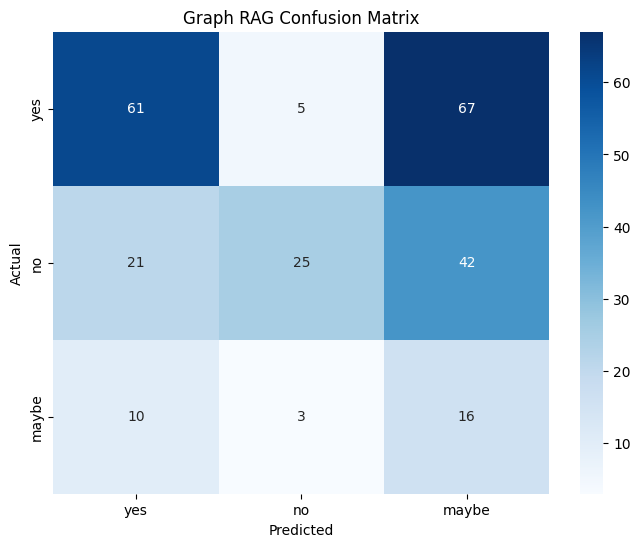


########################################
### SUCCESS CASES: Where Graph RAG was Correct
########################################

PMID: 10834864
Question: Risk factors for avascular necrosis of bone in patients with systemic lupus erythematosus: is there a role for antiphospholipid antibodies?
Ground Truth: NO | Pred: NO
------------------------------
Graph Context Used:
Relationship: (antiphospholipid antibodies) -[NO_SIGNIFICANT_ASSOCIATION_WITH]-> (avascular necrosis of bone)


Relationship: (avascular necrosis of bone) -[IS_COMPLICATION_OF]-> (systemic lupus erythematosus)


Relationship: (lupus anticoagulant) -[TYPE_OF]-> (antiphospholipid antibody status)


Relationship: (igm anticardiolipin antibodies) -[TYPE_OF]-> (antiphospholipid antibody status)


Relationship: (corticosteroid use) -[INVESTIGATED_AS_RISK_FACTOR_FOR]-> (avascular necrosis of bone)


Re...
------------------------------
Model Reasoning:
<thinking>
The Knowledge Graph explicitly states that there is **no signi

In [ ]:

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the Graph RAG Results
CHECKPOINT_FILE = "graph_rag_checkpoint.json"
with open(CHECKPOINT_FILE, 'r') as f:
    results_data = json.load(f)

# Convert to DataFrame for easier analysis
df = pd.DataFrame.from_dict(results_data, orient='index')
df['qid'] = df.index

# Ensure consistent labels for the matrix
LABELS = ["yes", "no", "maybe"]
y_true = df['ground_truth'].tolist()
y_pred = df['predicted_answer'].tolist()

# 2. Print Confusion Matrix & Classification Report
print("========== GRAPH RAG: CLASSIFICATION REPORT ==========")
print(classification_report(y_true, y_pred, target_names=LABELS, labels=LABELS))

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Graph RAG Confusion Matrix')
plt.show()

# 3. Qualitative Analysis: Successes and Failures
def print_case(row):
    print(f"PMID: {row['qid']}")
    print(f"Question: {row['question']}")
    print(f"Ground Truth: {row['ground_truth'].upper()} | Pred: {row['predicted_answer'].upper()}")
    print("-" * 30)
    print(f"Graph Context Used:\n{row['graph_context_used'][:500]}...") # Truncated for readability
    print("-" * 30)
    print(f"Model Reasoning:\n{row['raw_llm_output']}")
    print("=" * 80 + "\n")



In [6]:
print("\n" + "#" * 40)
print("### SUCCESS CASES: Where Graph RAG was Correct")
print("#" * 40 + "\n")
successes = df[df['is_correct'] == True].head(3) # Show top 3 successes
for _, row in successes.iterrows():
    print_case(row)





########################################
### SUCCESS CASES: Where Graph RAG was Correct
########################################

PMID: 10834864
Question: Risk factors for avascular necrosis of bone in patients with systemic lupus erythematosus: is there a role for antiphospholipid antibodies?
Ground Truth: NO | Pred: NO
------------------------------
Graph Context Used:
Relationship: (antiphospholipid antibodies) -[NO_SIGNIFICANT_ASSOCIATION_WITH]-> (avascular necrosis of bone)


Relationship: (avascular necrosis of bone) -[IS_COMPLICATION_OF]-> (systemic lupus erythematosus)


Relationship: (lupus anticoagulant) -[TYPE_OF]-> (antiphospholipid antibody status)


Relationship: (igm anticardiolipin antibodies) -[TYPE_OF]-> (antiphospholipid antibody status)


Relationship: (corticosteroid use) -[INVESTIGATED_AS_RISK_FACTOR_FOR]-> (avascular necrosis of bone)


Re...
------------------------------
Model Reasoning:
<thinking>
The Knowledge Graph explicitly states that there is **no signi

In [5]:
print("\n" + "#" * 40)
print("### FAILURE CASES: Where Graph RAG was Incorrect")
print("#" * 40 + "\n")
failures = df[df['is_correct'] == False].head(3) # Show top 3 failures
for _, row in failures.iterrows():
    print_case(row)

# 4. Error Type Distribution (The "Why")
maybe_errors = df[(df['ground_truth'] != 'maybe') & (df['predicted_answer'] == 'maybe')]
print(f"Total 'Over-cautious' errors (Maybe instead of Yes/No): {len(maybe_errors)}")
print(f"Percentage of total errors: {(len(maybe_errors)/len(df[df['is_correct']==False])*100):.2f}%")


########################################
### FAILURE CASES: Where Graph RAG was Incorrect
########################################

PMID: 11079675
Question: Pulmonary valve replacement in adults late after repair of tetralogy of fallot: are we operating too late?
Ground Truth: YES | Pred: MAYBE
------------------------------
Graph Context Used:
Relationship: (young adults (19-25 years)) -[OBSERVED_BMI_TREND]-> (slightly decreased)


Relationship: (pulmonary valve replacement (pvr)) -[SHOWED_NO_CHANGE_IN]-> (mean rvesv)


Relationship: (valve replacement) -[IS_TREATMENT_FOR]-> (prosthetic valve endocarditis (pve))


Relationship: (pulmonary valve replacement (pvr)) -[SHOWED_NO_CHANGE_IN]-> (mean rvedv)


Relationship: (cardiac surgery) -[INDICATED_FOR]-> (aortic valve replacement)


Relationship: (pulmonary valve replacement (pvr)) -[PE...
------------------------------
Model Reasoning:
<thinking>
The question asks whether performing pulmonary valve replacement (PVR) in adults late aft

GRAPH RAG: CONFUSION MATRIX

Rows = True Label, Cols = Predicted Label

             |      yes |       no |    maybe
---------------------------------------------
         YES |       61 |        5 |       67
          NO |       21 |       25 |       42
       MAYBE |       10 |        3 |       16

GRAPH RAG: CLASSIFICATION REPORT
              precision    recall  f1-score   support

         yes       0.66      0.46      0.54       133
          no       0.76      0.28      0.41        88
       maybe       0.13      0.55      0.21        29

    accuracy                           0.41       250
   macro avg       0.52      0.43      0.39       250
weighted avg       0.63      0.41      0.46       250

GRAPH RAG: ERROR BREAKDOWN
Total errors: 148
Over-cautious (maybe instead of yes/no): 109 (73.6%)
Wrong yes (yes instead of no/maybe): 21 (14.2%)
Wrong no (no instead of yes/maybe): 5 (3.4%)

ERRORS BY TRUE LABEL
True label =    YES: 72 errors out of 133 (54.1% error rate)
True labe

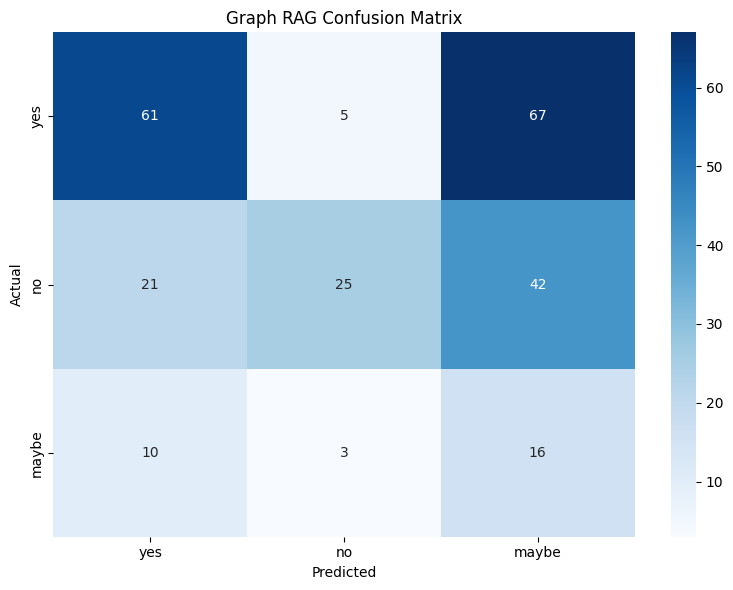

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load Graph RAG data
with open(GRAPH_FILE, 'r') as f:
    gdata = json.load(f)

df_g = pd.DataFrame.from_dict(gdata, orient='index')
df_g['qid'] = df_g.index

# 1. Confusion Matrix
LABELS = ['yes', 'no', 'maybe']
y_true_g = df_g['ground_truth'].tolist()
y_pred_g = df_g['predicted_answer'].tolist()

print("=" * 60)
print("GRAPH RAG: CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(y_true_g, y_pred_g, labels=LABELS)
print(f"\nRows = True Label, Cols = Predicted Label\n")
print(f"{'':>12} | {'yes':>8} | {'no':>8} | {'maybe':>8}")
print("-" * 45)
for i, lbl in enumerate(LABELS):
    print(f"{lbl.upper():>12} | {cm[i][0]:>8} | {cm[i][1]:>8} | {cm[i][2]:>8}")

# 2. Classification Report
print("\n" + "=" * 60)
print("GRAPH RAG: CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true_g, y_pred_g, labels=LABELS, target_names=LABELS))

# 3. Error type analysis
print("=" * 60)
print("GRAPH RAG: ERROR BREAKDOWN")
print("=" * 60)

errors_df = df_g[df_g['is_correct'] == False]
total_errors = len(errors_df)

# Over-cautious: predicted maybe, but true is yes or no
over_cautious = errors_df[(errors_df['predicted_answer'] == 'maybe') & (errors_df['ground_truth'] != 'maybe')]

# False yes: predicted yes but true is no or maybe
false_yes = errors_df[(errors_df['predicted_answer'] == 'yes') & (errors_df['ground_truth'] == 'no')]

# False no: predicted no but true is yes or maybe
false_no = errors_df[(errors_df['predicted_answer'] == 'no') & (errors_df['ground_truth'] == 'yes')]

print(f"Total errors: {total_errors}")
print(f"Over-cautious (maybe instead of yes/no): {len(over_cautious)} ({len(over_cautious)/total_errors*100:.1f}%)")
print(f"Wrong yes (yes instead of no/maybe): {len(false_yes)} ({len(false_yes)/total_errors*100:.1f}%)")
print(f"Wrong no (no instead of yes/maybe): {len(false_no)} ({len(false_no)/total_errors*100:.1f}%)")

# 4. Error distribution by true label
print("\n" + "=" * 60)
print("ERRORS BY TRUE LABEL")
print("=" * 60)
for lbl in LABELS:
    subset = df_g[df_g['ground_truth'] == lbl]
    errors = subset[subset['is_correct'] == False]
    print(f"True label = {lbl.upper():>6}: {len(errors)} errors out of {len(subset)} ({len(errors)/len(subset)*100:.1f}% error rate)")

# 5. Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Graph RAG Confusion Matrix')
plt.tight_layout()
plt.show()


## Retrieval Quality vs QA Accuracy Correlation
Analyzes whether better retrieval (higher hit rate, higher MRR) correlates with better QA accuracy for Graph RAG.

RETRIEVAL RANK vs QA ACCURACY (Graph RAG)

Retrieval Rank Bin -> QA Accuracy (%)
----------------------------------------
      Rank 1: 48.2%
    Rank 2-3: 39.7%
    Rank 4-5: 29.4%
   Rank 6-10: 30.8%
    Rank 10+: 35.3%


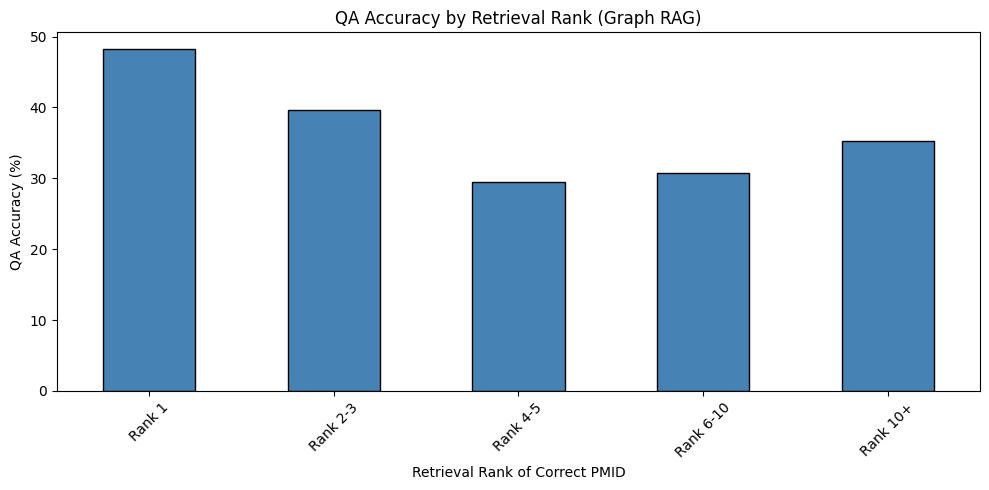

In [13]:
# For each question, compute retrieval rank of correct PMID
retrieval_ranks = []
correct_flags = []

for qid, v in graph_data.items():
    retrieved_rels = v.get('retrieved_rels', [])
    gt = v.get('ground_truth', '')
    pred = v.get('predicted_answer', '')
    
    rank = -1
    for i, rel in enumerate(retrieved_rels):
        if str(rel.get('pmid', '')) == str(qid):
            rank = i + 1
            break
    
    retrieval_ranks.append(rank if rank > 0 else len(retrieved_rels) + 1)
    correct_flags.append(1 if pred == gt else 0)

# Bin by retrieval rank
df_corr = pd.DataFrame({'rank': retrieval_ranks, 'correct': correct_flags})
df_corr['rank_bin'] = pd.cut(df_corr['rank'], bins=[0, 1, 3, 5, 10, 50, 1000], labels=['Rank 1', 'Rank 2-3', 'Rank 4-5', 'Rank 6-10', 'Rank 10+', 'No Hit'])

acc_by_rank = df_corr.groupby('rank_bin', observed=True)['correct'].mean() * 100

print("=" * 60)
print("RETRIEVAL RANK vs QA ACCURACY (Graph RAG)")
print("=" * 60)
print("\nRetrieval Rank Bin -> QA Accuracy (%)")
print("-" * 40)
for bin_name, acc in acc_by_rank.items():
    print(f"{bin_name:>12}: {acc:.1f}%")

# Plot
plt.figure(figsize=(10, 5))
acc_by_rank.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('QA Accuracy by Retrieval Rank (Graph RAG)')
plt.xlabel('Retrieval Rank of Correct PMID')
plt.ylabel('QA Accuracy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
